In [26]:
#pip install folium

In [27]:
#pip install geopandas

In [28]:
import numpy as np 
import pandas as pd

import folium
from folium import plugins
import geopandas as gpd
import branca

import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from textwrap import wrap
from matplotlib.lines import Line2D
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

from scipy import stats
from scipy.stats import ttest_ind

plt.rcParams["font.family"] = "DejaVu Sans"

background_color='#F5F4EF'

HEADER = '\033[95m'
OKBLUE = '\033[94m'
OKCYAN = '\033[96m'
OKGREEN = '\033[92m'
WARNING = '\033[93m'
FAIL = '\033[91m'
ENDC = '\033[0m'
BOLD = '\033[1m'
UNDERLINE = '\033[4m'

from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))

## Print colored text 
https://stackoverflow.com/questions/287871/how-to-print-colored-text-to-the-terminal
### Includes other color options

In [29]:
class color_font:
    S = BOLD + OKBLUE +  UNDERLINE   #S = Start
    E = ENDC #E = End
    
print(color_font.S+"Datasets & Libraries"+color_font.E)

Datasets & Libraries


## Import dataset

In [30]:
population = pd.read_csv('Olympic/population_by_country_2020.csv')
regions = pd.read_csv('Olympic/120Yrs-Olympic-History/noc_regions.csv')

df = pd.read_csv('Olympic/120Yrs-Olympic-History/athlete_events.csv')
df_21 = pd.read_csv('Olympic/2021-Medal/Tokyo 2021 dataset.csv')
df_21_full = pd.read_csv('Olympic/2021-Medal/Tokyo 2021 dataset.csv')

# For geographic plotting
url = 'https://raw.githubusercontent.com/python-visualization/folium/master/examples/data'
country_shapes = f'{url}/world-countries.json'

In [31]:
df.sample(3)

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
142523,71507,Czesaw Ignacy Lorenc,M,27.0,183.0,76.0,Poland,POL,1952 Summer,1952,Summer,Helsinki,Rowing,Rowing Men's Coxed Pairs,NaN
52085,26774,Frederik Albert De Waele,M,33.0,NaN,NaN,Belgium,BEL,1952 Summer,1952,Summer,Helsinki,Gymnastics,Gymnastics Men's Individual All-Around,NaN
90943,46080,Johan Georg Harmenberg (kerman-),M,25.0,179.0,71.0,Sweden,SWE,1980 Summer,1980,Summer,Moskva,Fencing,"Fencing Men's epee, Team",NaN


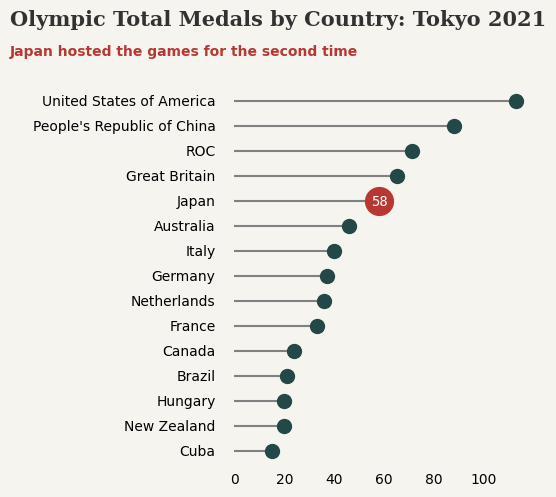

In [32]:
fig, ax = plt.subplots(figsize=(4, 5), facecolor=background_color)

temp = df_21_full[:15].sort_values(by='Total')
my_range=range(1,len(df_21_full[:15]['Team/NOC'])+1)

ax.set_facecolor(background_color)

plt.hlines(y=my_range, xmin=0, xmax=temp['Total'], color='gray')
plt.plot(temp['Total'], my_range, "o",markersize=10, color='#244747')
plt.plot(temp['Total'][2], my_range[10], "o",markersize=20,color='#B73832')

Xstart, Xend = ax.get_xlim()
Ystart, Yend = ax.get_ylim()

ax.tick_params(axis=u'both', which=u'both',length=0)
ax.set_xlabel("Total Medals",fontfamily='DejaVu Sans',loc='left',color='gray')
ax.set_axisbelow(True)

for s in ['top','right','bottom','left']:
    ax.spines[s].set_visible(False)
    
ax.text(-90,Yend+2.3, 'Olympic Total Medals by Country: Tokyo 2021', fontsize=15,
                                fontweight='bold',fontfamily='serif',color='#323232')
ax.text(-90,Yend+1.1, 'Japan hosted the games for the second time', fontsize=10,
                            fontweight='bold',color='#B73832')
#ax.text(-100,Yend+1, 'Not Hosting', fontsize=10,fontweight='bold',fontfamily='sansserif',color='#244747')

plt.yticks(my_range, temp['Team/NOC'])
plt.xlabel('')

ax.annotate(temp['Total'][2], xy=(54.86,10.95), va = 'center', ha='left',fontweight='light', 
            fontfamily='monospace',fontsize=10, color='white',rotation=0)
plt.show()

## Top 15 Medal Countries

In [33]:
df_21_full[['Rank','Team/NOC','Bronze Medal','Silver Medal','Gold Medal','Total']].iloc[:15]

,Rank,Team/NOC,Bronze Medal,Silver Medal,Gold Medal,Total
0,1,United States of America,33,41,39,113
1,2,People's Republic of China,18,32,38,88
2,3,Japan,17,14,27,58
3,4,Great Britain,22,21,22,65
4,5,ROC,23,28,20,71
5,6,Australia,22,7,17,46
6,7,Netherlands,14,12,10,36
7,8,France,11,12,10,33
8,9,Germany,16,11,10,37
9,10,Italy,20,10,10,40


In [34]:
def highlight(nation):
    if nation['Team/NOC'] == 'Japan':
        return ['background-color: #f3f2f1']*6
    else:
        return ['background-color: white']*6

df_21_full[['Rank','Team/NOC','Bronze Medal','Silver Medal','Gold Medal','Total']]\
.iloc[:15].style.set_caption('Medals by Country: Summer Olympic Games sorted by Gold Medals [Top 15]')\
.bar(subset=['Gold Medal'], color='#f0c05a')\
.bar(subset=['Silver Medal'], color='Lightgray')\
.bar(subset=['Bronze Medal'], color='#a97142')\
.hide(axis="index").apply(highlight, axis=1)

Rank,Team/NOC,Bronze Medal,Silver Medal,Gold Medal,Total
1,United States of America,33,41,39,113
2,People's Republic of China,18,32,38,88
3,Japan,17,14,27,58
4,Great Britain,22,21,22,65
5,ROC,23,28,20,71
6,Australia,22,7,17,46
7,Netherlands,14,12,10,36
8,France,11,12,10,33
9,Germany,16,11,10,37
10,Italy,20,10,10,40


## Geographic visual - showing which countries have hosted the Olympics, and where medals tend to go

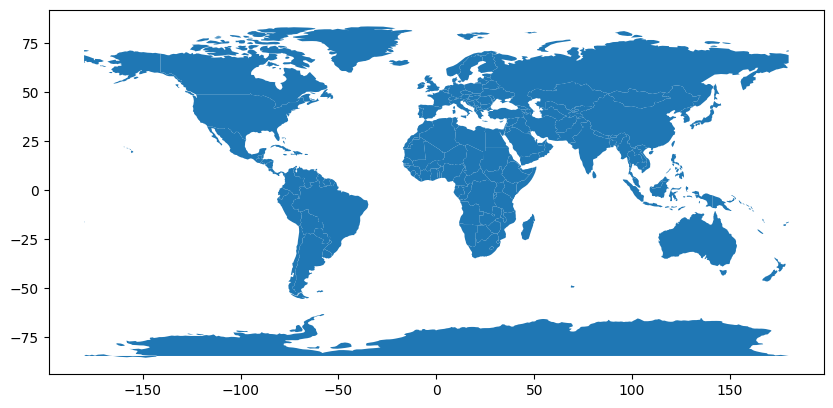

In [35]:
# For geographic plotting
global_polygons = gpd.read_file(country_shapes)
global_polygons.to_file('global_polygons.geojson', driver = 'GeoJSON')

global_polygons.plot(figsize=(10,5)) # test map of the globe

# Tabular
df = pd.merge(df,regions,left_on='NOC',right_on='NOC')
df = df.query('Season == "Summer"') # Only interested in Summer Olympics for this project

## Replacing the country name with common values

In [36]:
df.replace('USA', "United States of America", inplace = True)
df.replace('Tanzania', "United Republic of Tanzania", inplace = True)
df.replace('Democratic Republic of Congo', "Democratic Republic of the Congo", inplace = True)
df.replace('Congo', "Republic of the Congo", inplace = True)
df.replace('Lao', "Laos", inplace = True)
df.replace('Syrian Arab Republic', "Syria", inplace = True)
df.replace('Serbia', "Republic of Serbia", inplace = True)
df.replace('Czechia', "Czech Republic", inplace = True)
df.replace('UAE', "United Arab Emirates", inplace = True)
df.replace('UK', "United Kingdom", inplace = True)

population.replace('United States', "United States of America", inplace = True)
population.replace('Czech Republic (Czechia)', "Czech Republic", inplace = True)
population.replace('DR Congo', "Democratic Republic of the Congo", inplace = True)
population.replace('Serbia', "Republic of Serbia", inplace = True)
population.replace('Tanzania', "United Republic of Tanzania", inplace = True)

df_21_full.replace('Great Britain', "United Kingdom", inplace = True)
df_21_full.replace("People's Republic of China", "China", inplace = True)
df_21_full.replace("ROC", "Russia", inplace = True)

## map country to city

In [37]:
# Function to map country to city. You may try python switch case instead of multiple elif
def host_country(col):
    if col == "Rio de Janeiro":
        return "Brazil"
    elif col == "London":
        return "United Kingdom"
    elif col == "Beijing":
        return  "China"
    elif col == "Athina":
        return  "Greece"
    elif col == "Sydney" or col == "Melbourne":
        return  "Australia"
    elif col == "Atlanta" or col == "Los Angeles" or col == "St. Louis":
        return  "United States of America"
    elif col == "Barcelona":
        return  "Spain"
    elif col == "Seoul":
        return  "South Korea"
    elif col == "Moskva":
        return  "Russia"
    elif col == "Montreal":
        return  "Canada"
    elif col == "Munich" or col == "Berlin":
        return  "Germany"
    elif col == "Mexico City":
        return  "Mexico"
    elif col == "Tokyo":
        return  "Japan"
    elif col == "Roma":
        return  "Italy"
    elif col == "Paris":
        return  "France"
    elif col == "Helsinki":
        return  "Finland"
    elif col == "Amsterdam":
        return  "Netherlands"
    elif col == "Antwerpen":
        return  "Belgium"
    elif col == "Stockholm":
        return  "Sweden"
    else:
        return "Other"

# Applying this function
df['Host_Country'] = df['City'].apply(host_country)

## Creat new dataframe containing host nation data

In [38]:
df_new = df.groupby(['Year','Host_Country','region','Medal']
                   )['Medal'].count().unstack().fillna(0).astype(int).reset_index()

df_new['Is_Host'] = np.where(df_new['Host_Country'] == df_new['region'],1,0)
df_new['Total Medals'] = df_new['Bronze'] + df_new['Silver'] + df_new['Gold']

In [ ]:
# Preparing to add 2021 data to our historic df
df_21_full_refined = df_21_full[['Team/NOC', "Gold Medal", "Silver Medal", "Bronze Medal"]]
df_21_full_refined.loc[df_21_full_refined.index,['Total Medals']] = df_21_full_refined[["Gold Medal", 
                                                            "Silver Medal", "Bronze Medal"]].sum(axis=1)
df_21_full_refined.loc[df_21_full_refined.index,['Year']] = 2021

df_21_full_refined = df_21_full_refined.rename(columns={'Gold Medal':'Gold', 'Silver Medal':'Silver',
                                                            'Bronze Medal':'Bronze'})

df_21_full_refined['Is_Host'] = np.where(df_21_full_refined['Team/NOC'] == 'Japan',1,0)
df_21_full_refined['Host_Country'] = 'Japan'
df_21_full_refined = df_21_full_refined.rename(columns={'Team/NOC':'region'})

# Adding 2021 data to historic
df_new = pd.concat([df_new, df_21_full_refined],axis = 0)

# Removing Russia as many Olympic games were competed in as the Soviet Union, 
# containing several modern day nations
df_new = df_new.query("region != 'Russia' | region != 'ROC'")

In [ ]:
df_21_full_refined.sample()

In [ ]:
df_new.sample()

## Medal in all years history

In [ ]:
medals = df.groupby(['region','Medal'])['Medal'].count().unstack().fillna(0).astype(int)

medals['Total'] = medals['Bronze'] + medals['Silver'] + medals['Gold']

medals = medals[['Bronze','Silver','Gold','Total']].sort_values(by='Total', ascending=False)

medals.iloc[:15].style.set_caption('Medals by Country: Summer Olympic Games [Top 15]')\
.bar(subset=['Gold'], color='#f0c05a')\
.bar(subset=['Silver'], color='Lightgray')\
.bar(subset=['Bronze'], color='#a97142')\
.background_gradient(subset=['Total'], cmap='BuGn')

In [ ]:
df_new.sample()

## Distribution of medals on a map

In [ ]:
host_list = list(df_new.query("Is_Host == 1")['Host_Country'].value_counts().index)

medals_temp = medals.reset_index()
medals_map = pd.merge(global_polygons, medals_temp, left_on='name',right_on='region')
medals_map['Hosted'] = np.where(medals_map['name'].isin(host_list),1,0)

In [ ]:
def rd2(x):
    return round(x, 2)

Temp = medals_map

minimum, maximum = Temp["Total"].quantile([0.05, 0.95]).apply(rd2)
mean = round(Temp["Total"].mean(), 2)

colormap = branca.colormap.LinearColormap(
    colors=["#f2f0f7", "#cbc9e2", "#9e9ac8", "#756bb1", "#54278f"],
    index=Temp["Total"].quantile([0.25, 0.5, 0.85, 0.95]),
    vmin=minimum,
    vmax=maximum,
)

colormap.caption = "Total medals"

from folium.plugins import Search
from folium.plugins import HeatMap

m = folium.Map(location=(50,0),zoom_start=3)

def style_function(x):
    return { "fillColor": colormap(x["properties"]["Total"]),
                "color": "black",
                "weight": 2,
                "fillOpacity": 0.5, }

Map_Layer = folium.GeoJson(
    Temp,
    name="Medals",
    style_function=style_function,
    tooltip=folium.GeoJsonTooltip(
        fields=["name","Total","Gold","Silver","Bronze"], aliases=["Country","Total Medals",
                                                    "Gold","Silver","Bronze"], localize=True ),
).add_to(m)

plugins.Search(Map_Layer,position='topleft',
                           search_zoom=5,placeholder="Search for a country",weight=3,
                           search_label='region',
                           geom_type='Polygon').add_to(m)

minimap = plugins.MiniMap()
m.add_child(minimap)
    
folium.LayerControl().add_to(m)
colormap.add_to(m)

m

## Olympic medal by countries

In [ ]:
fig, ax = plt.subplots(1,1, figsize=(16,8), facecolor=background_color)

sns.scatterplot(data=df_new.query("Is_Host == 0"), x='Year', y='Total Medals', s=45, 
                ec='black', color='#244747',ax=ax)
sns.scatterplot(data=df_new.query("Is_Host == 1"), x='Year', y='Total Medals', s=75, 
                ec='black', color='#B73832',ax=ax)

Xstart, Xend = ax.get_xlim()
Ystart, Yend = ax.get_ylim()

ax.tick_params(axis=u'both', which=u'both',length=0)
ax.set_ylabel("Total Medals",fontfamily='monospace',loc='bottom',color='gray')
ax.set_xlabel("")

ax.set_facecolor(background_color)
ax.set_axisbelow(True)


for s in ['top','right','bottom','left']:
    ax.spines[s].set_visible(False)
    

ax.text(Xstart,Yend+80, 'Olympic Medals by Country: Hosting always helps', fontsize=15,
        fontweight='bold',fontfamily='serif',color='#323232')
ax.text(Xstart,Yend+40, 'Host Medals', fontsize=10,fontweight='bold',color='#B73832')
ax.text(Xstart,Yend+5, 'Others', fontsize=10,fontweight='bold',color='#244747')

plt.show()

## Olympic Medals by Country: Hosts through the years

In [ ]:
fig, ax = plt.subplots(1,1, figsize=(16, 8), facecolor=background_color)

# top 20
top_list_ = df_new.groupby('region')['Total Medals'].mean().sort_values(ascending=False)\
.reset_index()[:20].sort_values(by='Total Medals',ascending=True)

plot = 1
for country in top_list_['region']:
    mean = df_new[df_new['region'] == country].groupby('region')['Total Medals'].mean()
    # historic scores
    sns.scatterplot(data=df_new[df_new['region'] == country], y=plot, x='Total Medals',
                    color='lightgray',s=50,ax=ax)
    # mean score
    sns.scatterplot(data=df_new[df_new['region'] == country], y=plot, x=mean,color='#244747',
                    ec='black',linewidth=1,s=75,ax=ax)
    # Hosting score
    sns.scatterplot(data=(df_new[(df_new['region'] == country) & (df_new['Is_Host'] == 1)]), 
                    y=plot, x='Total Medals',color='#B73832',ec='black',linewidth=1,s=75,ax=ax)   
    plot += 1

Xstart, Xend = ax.get_xlim()
Ystart, Yend = ax.get_ylim()

ax.set_yticks(top_list_.index+1)
ax.set_yticklabels(top_list_['region'][::-1], fontdict={'horizontalalignment': 'right'}, alpha=0.7)
ax.tick_params(axis=u'both', which=u'both',length=0)
ax.set_xlabel("Total Medals",fontfamily='monospace',loc='left',color='gray')
ax.set_facecolor(background_color)
ax.hlines(y=top_list_.index+1, xmin=0, xmax=Xend, color='gray', alpha=0.5, linewidth=.3, linestyles='--')
ax.set_axisbelow(True)

for s in ['top','right','bottom','left']:
    ax.spines[s].set_visible(False)
    
ax.text(0,Yend+3.5, 'Olympic Medals by Country: Hosts through the years', fontsize=15,
                                                            fontweight='bold', color='#323232')
ax.text(0,Yend+2.1, 'Hosting', fontsize=10,fontweight='bold', color='#B73832')
ax.text(0,Yend+1, 'Average', fontsize=10,fontweight='bold', color='#244747')

plt.show()

## Host countries on map with total medal over years
Folium makes it easy to visualize data that's been manipulated in Python on an interactive leaflet map.
https://python-visualization.github.io/folium/latest/

In [ ]:
Temp = medals_map

colormap = branca.colormap.LinearColormap(
    colors=["#f2f0f7",  "#B73832"],
    index=Temp["Hosted"].quantile([0.05, 0.5]),
    vmin=0,
    vmax=1, )

colormap.caption = "Hosted"

from folium.plugins import Search
from folium.plugins import HeatMap

m = folium.Map(location=(50,0),zoom_start=3)

def style_function(x):
    return { "fillColor": colormap(x["properties"]["Hosted"]),
                "color": "black",
                "weight": 2,
                "fillOpacity": 0.5,   }

Map_Layer = folium.GeoJson(
    Temp,
    name="Hosted",
    style_function=style_function,
    tooltip=folium.GeoJsonTooltip(
        fields=["name","Total","Gold","Silver","Bronze"], aliases=["Country",
                                "Total Medals","Gold","Silver","Bronze"], localize=True
    ),
).add_to(m)

plugins.Search(Map_Layer,position='topleft',
                           search_zoom=5,placeholder="Search for a country",weight=3,
                           search_label='region',
                           geom_type='Polygon').add_to(m)

minimap = plugins.MiniMap()
m.add_child(minimap)
    
folium.LayerControl().add_to(m)
colormap.add_to(m)

m

## Total Olympic Medals for the United States of America

In [ ]:
temp = df_new.query("region == 'United States of America'")

fig, ax = plt.subplots(1, 1, figsize=(16, 8), facecolor=background_color)

color = ['#B73832' if i == 1 else '#244747' for i in temp['Is_Host']]

ax.bar(temp['Year'], temp['Total Medals'],width=3, color=color, ec='black')
ax.set_facecolor(background_color)
ax.grid(which='both', axis='y', zorder=5, color='gray', linestyle=':', dashes=(1,5))
ax.set_axisbelow(True)

for s in ['top', 'right']:
    ax.spines[s].set_visible(False)

Xstart, Xend = ax.get_xlim()
Ystart, Yend = ax.get_ylim()

ax.text(Xstart,Yend+50, 'Total Olympic Medals for the United States of America', fontsize=15,
        fontweight='bold',color='#323232')
ax.text(Xstart,Yend+25, 'Hosting', fontsize=10,fontweight='bold',color='#B73832')

plt.show()

## Olympic Medals for the United Kingdom

In [ ]:
stack_temp = df_new.query("region == 'United Kingdom' & Year > 1945")[['Year','Bronze','Silver','Gold']].set_index('Year')
stack_temp = (stack_temp.T/stack_temp.sum(axis=1)).cumsum().T

fig, ax = plt.subplots(1,1, figsize=(18,5), facecolor=background_color)

# Host years
ax.axvspan(1950,1946, facecolor='lightgray',alpha=0.7)
ax.axvspan(2014,2010, facecolor='lightgray',alpha=0.7)

color = ["#a97142", "lightgray", '#f0c05a']
medals_list = ['Bronze', 'Silver', 'Gold']

for i, medal in enumerate(medals_list[::-1]):
    sentims = stack_temp[medal]
    ax.bar(sentims.index, sentims, color=color[::-1][i], label=medal, width=2.25, ec='black')

ax.set_facecolor(background_color)

for s in ['top', 'right']:
    ax.spines[s].set_visible(False)
    
Xstart, Xend = ax.get_xlim()
Ystart, Yend = ax.get_ylim()

ax.set_xlim(Xstart+3, Xend)
ax.grid(which='both', axis='x', zorder=5, color='gray', linestyle=':', dashes=(1,5))
ax.set_axisbelow(True)
ax.get_yaxis().set_visible(False)

ax.text(Xstart+3,Yend+0.13, 'Olympic Medals for the United Kingdom', fontsize=15,fontweight='bold',
                                                                            color='#323232')
ax.text(Xstart+3,Yend+0.055, 'Hosting', fontsize=10,fontweight='bold', color='gray')

plt.show()

## Overall medal distribution

In [ ]:
fig = plt.figure(figsize=(18,10), facecolor=background_color)

colors = ['#a97142', 'lightgray', '#f0c05a', '#244747']

num = 0
variables = ['Bronze', 'Silver', 'Gold', 'Total Medals']

plots = [(0,0), (0,1), (0,2), (1,0)]

data = df_new

for item in variables:
    if plots[num] == plots[-1]:
        colspan=3
    else: 
        colspan=1
        
    plt.subplot2grid((2,3), (plots[num]), colspan=colspan)
    
    ax = sns.kdeplot(data=data, x=item,color=colors[num],fill=True,  alpha=0.9, ec='black', cut=5)
    ax.set_facecolor(background_color)
    ax.tick_params(axis='y', left=False)
    ax.get_yaxis().set_visible(False)
    ax.set_axisbelow(True)
    ax.set_xlabel(item)
    ax.grid(which='major', axis='x', zorder=5, color='gray', linestyle=':', dashes=(1,5))
    for s in ["top","right","left"]:
        ax.spines[s].set_visible(False)
    
    plt.xticks(list(np.arange(0,data[item].max()+25,25)))
    num +=1 

    
Xstart, Xend = ax.get_xlim()
Ystart, Yend = ax.get_ylim()

fig.text(0.03,1.05, 'Overall Distribution of Medals: Positively Skewed', fontsize=25,
         fontweight='bold',color='#323232')
   
plt.tight_layout()
plt.show()

### We note that the medals are not distributed normally. They are positively skewed. To mitigate against this, I will take the natural log of the total medals.

In [ ]:
host_list = list(df_new.query("Is_Host == 1")['Host_Country'].value_counts().index)

df_new['Total_Medals_NaturalLog'] = np.log(df_new['Total Medals'])

Not_hosting_samples = df_new[df_new['region'].isin(host_list)]\
.query("Is_Host == 0")['Total_Medals_NaturalLog'].count()

hosting_samples = df_new[df_new['region'].isin(host_list)]\
.query("Is_Host == 1")['Total_Medals_NaturalLog'].count()

Not_hosting_mean = df_new[df_new['region'].isin(host_list)]\
.query("Is_Host == 0")['Total_Medals_NaturalLog'].mean()

hosting_mean = df_new[df_new['region'].isin(host_list)]\
.query("Is_Host == 1")['Total_Medals_NaturalLog'].mean()

Not_hosting_std = df_new[df_new['region'].isin(host_list)]\
.query("Is_Host == 0")['Total_Medals_NaturalLog'].std()

hosting_std = df_new[df_new['region'].isin(host_list)].\
query("Is_Host == 1")['Total_Medals_NaturalLog'].std()

In [ ]:
print(color_font.S+"Key Statistics"+color_font.E)
print("Mean Natural Log of Total Medals when Not Hosting:\n",Not_hosting_mean)
print("Mean Natural Log of Total Medals when Hosting:\n",hosting_mean,"\n")

Not_hosting_std_error = Not_hosting_std/np.sqrt(Not_hosting_samples)
print("Standard Error of Natural Log of Total Medals when Not Hosting:\n",Not_hosting_std_error)

hosting_std_error = hosting_std/np.sqrt(hosting_samples)
print("Standard Error of Natural Log of Total Medals when Not Hosting:\n",hosting_std_error)

## Comparing Means when Hosting & Not Hosting

In [ ]:
fig, ax = plt.subplots(1,1, figsize=(16,8), facecolor=background_color)
ax.set_facecolor(background_color)
sns.kdeplot(data=df_new[df_new['region'].isin(host_list)].query("Is_Host == 1"), 
            x='Total_Medals_NaturalLog',fill=True,color='#B73832',alpha=0.9, ax=ax)
sns.kdeplot(data=df_new[df_new['region'].isin(host_list)].query("Is_Host == 0"), 
            x='Total_Medals_NaturalLog', fill=True, color='#244747',alpha=0.7, ax=ax)

ax.axvline(color='lightgray',x=Not_hosting_mean+(3*Not_hosting_std_error))
ax.axvline(color='lightgray',x=Not_hosting_mean-(3*Not_hosting_std_error))
ax.axvspan(Not_hosting_mean-(3*Not_hosting_std_error), Not_hosting_mean+(3*Not_hosting_std_error), 
           alpha=0.5, color='#f3f2f1')

#ax.axvline(x=Not_hosting_mean)

#ax.axvline(x=hosting_mean)
ax.axvline(color='lightgray',x=hosting_mean+(3*hosting_std_error))
ax.axvline(color='lightgray',x=hosting_mean-(3*hosting_std_error))
ax.axvspan(hosting_mean-(3*hosting_std_error), hosting_mean+(3*hosting_std_error), 
           alpha=0.5, color='#f3f2f1')

for s in ['top','left', 'bottom', 'right']:
    ax.spines[s].set_visible(False)
    
ax.set_xlabel("Natural Log of Total Medals",fontfamily='monospace',loc='left',color='gray')
ax.get_yaxis().set_visible(False)
ax.tick_params(axis = 'both', which = 'major', labelsize = 10)

ax.tick_params(axis='both', which='both',left=False, bottom=False,labelbottom=True) 

Xstart, Xend = ax.get_xlim()
Ystart, Yend = ax.get_ylim()

ax.text(Xstart,Yend, 'Comparing Means when Hosting & Not Hosting', fontsize=15,
        fontweight='bold',color='#323232')
ax.text(Xstart,Yend-0.02, 'Hosting', fontsize=10,fontweight='bold',color='#B73832')

plt.show()

Above we have plotted the distributions of the natural log of the mean total medals host nations have acheived when they host, and when they do not host.

The grey boxes reprseent 3 standard errors above & below the mean values. We note that these areas do not overlap. This suggests that the liklihood that hosting does not imprive performance is extremely small. In fact, it is overwhelmingly small.